# 04: Churn Driver Analysis

**Business question:** Which user behaviors and subscription attributes most strongly
predict churn and by how much?

**Approach:** Logistic regression on the engineered feature set. The model is used here
as an interpretability tool, not a prediction engine. Logistic regression coefficients
(converted to odds ratios) give a clean, stakeholder-legible answer to the business
question: *"If a user's auto-renew rate drops, how much more likely are they to churn?"*

**Input:** `data/model_ready.parquet` (from Notebook 03)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "../../data/"

## 1. Load Data

In [2]:
df = pd.read_parquet(DATA_DIR + "model_ready.parquet")
print(f"Loaded: {df.shape}")
print(f"Churn rate: {df['is_churn'].mean():.2%}  ({df['is_churn'].sum():,} churned / {len(df):,} total)")

# Drop redundant features:
#   - High-correlation pairs flagged in NB03
#   - plan_days_last: continuous version of the plan one-hots -- keeping both creates
#     multicollinearity and makes coefficients uninterpretable
#   - plan_30d: reference category (98% of users are on 30-day plans; coefficients
#     for plan_90d and plan_180d will be read as "compared to a 30-day plan user")


drop_cols = ["auto_renew_last", "plan_365d", "log_engagement_score",
             "plan_days_last", "plan_30d"]
df.drop(columns=drop_cols, inplace=True)

target = "is_churn"
feature_cols = [c for c in df.columns if c != target]
X = df[feature_cols]
y = df[target]
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")

Loaded: (933578, 18)
Churn rate: 6.20%  (57,895 churned / 933,578 total)

Features (12): ['days_since_last_txn', 'num_cancellations', 'auto_renew_rate', 'avg_discount_pct', 'log_days_last_30', 'avg_daily_secs_last_30', 'completion_rate_last_30', 'listening_decay_slope', 'is_discounted', 'high_cancel_flag', 'plan_180d', 'plan_90d']


## 2. Train / Test Split and Scaling

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standard scaling is required for LR so coefficients are comparable across features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test churn rate: {y_test.mean():.2%}")

Train: (746862, 12)  |  Test: (186716, 12)
Train churn rate: 6.20%  |  Test churn rate: 6.20%


## 3. Logistic Regression

In [4]:
lr = LogisticRegression(
    C=1.0,
    class_weight="balanced",  # compensate for 6% churn imbalance
    max_iter=1000,
    solver="lbfgs",
    random_state=42,
)
lr.fit(X_train_scaled, y_train)

y_prob = lr.predict_proba(X_test_scaled)[:, 1]
auc = roc_auc_score(y_test, y_prob)
print(f"AUC: {auc:.4f}  (1.0 = perfect, 0.5 = random)")
print(f"\n{classification_report(y_test, (y_prob >= 0.5).astype(int), target_names=['Retained', 'Churned'])}")

AUC: 0.9665  (1.0 = perfect, 0.5 = random)

              precision    recall  f1-score   support

    Retained       0.99      0.91      0.95    175137
     Churned       0.39      0.92      0.55     11579

    accuracy                           0.91    186716
   macro avg       0.69      0.91      0.75    186716
weighted avg       0.96      0.91      0.92    186716



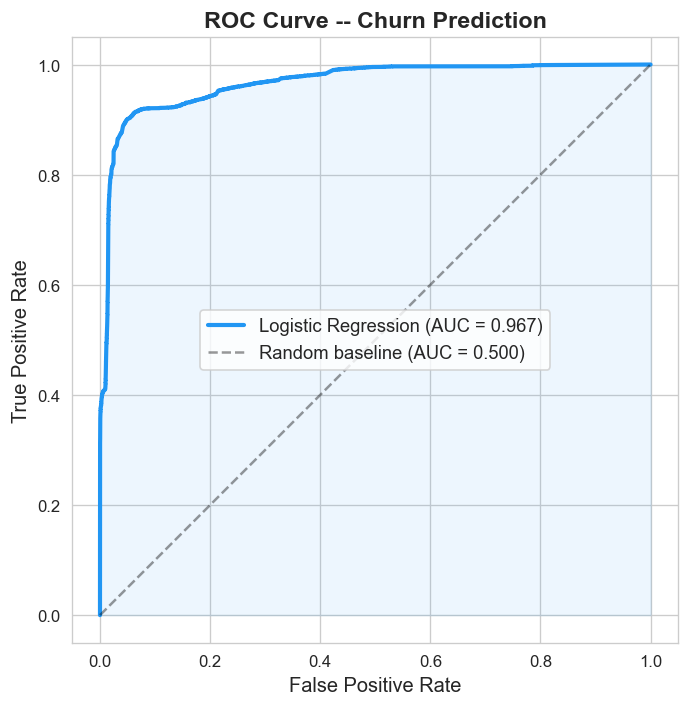

In [ ]:
# ROC curve
# confirms the model has real discriminatory power before we trust its coefficients

fpr, tpr, _ = roc_curve(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2.5, color="#2196F3", label=f"Logistic Regression (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random baseline (AUC = 0.500)")
ax.fill_between(fpr, tpr, alpha=0.08, color="#2196F3")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curve -- Churn Prediction", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig(DATA_DIR + "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Churn Driver Analysis: Odds Ratios

The logistic regression coefficient for feature $x$ tells us: a 1-SD increase in $x$
changes the **log-odds of churn** by that amount (features are scaled, so coefficients
are directly comparable).

Converting to **odds ratios** (`exp(coef)`) makes this stakeholder-legible:
- OR > 1 → feature **increases** churn risk
- OR < 1 → feature **decreases** churn risk
- OR = 1.5 → 50% higher odds of churning per 1-SD increase

In [6]:
# Build odds ratio table

coefs = pd.Series(lr.coef_[0], index=feature_cols)
odds_ratios = np.exp(coefs)

#feature labels for presentation

labels = {
    "days_since_last_txn":      "Days since last transaction",
    "num_cancellations":        "Number of cancellations",
    "auto_renew_rate":          "Auto-renew rate",
    "avg_discount_pct":         "Avg discount received",
    "log_days_last_30":         "Active listening days (last 30d)",
    "avg_daily_secs_last_30":   "Avg daily listening time",
    "completion_rate_last_30":  "Song completion rate (last 30d)",
    "listening_decay_slope":    "Listening trend (decay slope)",
    "is_discounted":            "Ever received a discount",
    "high_cancel_flag":         "2+ cancellations flag",
    "plan_90d":                 "On 90-day plan (vs. 30-day)",
    "plan_180d":                "On 180-day plan (vs. 30-day)",
}

driver_df = pd.DataFrame({
    "feature": feature_cols,
    "label": [labels.get(f, f) for f in feature_cols],
    "coefficient": coefs.values,
    "odds_ratio": odds_ratios.values,
}).sort_values("coefficient", ascending=False).reset_index(drop=True)

driver_df["direction"] = driver_df["coefficient"].apply(
    lambda c: "Increases churn risk" if c > 0 else "Reduces churn risk"
)
driver_df["pct_change_in_odds"] = ((driver_df["odds_ratio"] - 1) * 100).round(1)

print("Churn Driver Table (sorted by impact):\n")
print(driver_df[["label", "odds_ratio", "pct_change_in_odds", "direction"]].to_string(index=False))

Churn Driver Table (sorted by impact):

                           label  odds_ratio  pct_change_in_odds            direction
     Days since last transaction   15.287321              1428.7 Increases churn risk
         Number of cancellations    4.922967               392.3 Increases churn risk
           Avg discount received    1.479990                48.0 Increases churn risk
    On 180-day plan (vs. 30-day)    1.474480                47.4 Increases churn risk
     On 90-day plan (vs. 30-day)    1.356172                35.6 Increases churn risk
Active listening days (last 30d)    1.214957                21.5 Increases churn risk
   Listening trend (decay slope)    1.000000                 0.0   Reduces churn risk
 Song completion rate (last 30d)    0.957849                -4.2   Reduces churn risk
        Avg daily listening time    0.954393                -4.6   Reduces churn risk
        Ever received a discount    0.822212               -17.8   Reduces churn risk
           2+ 

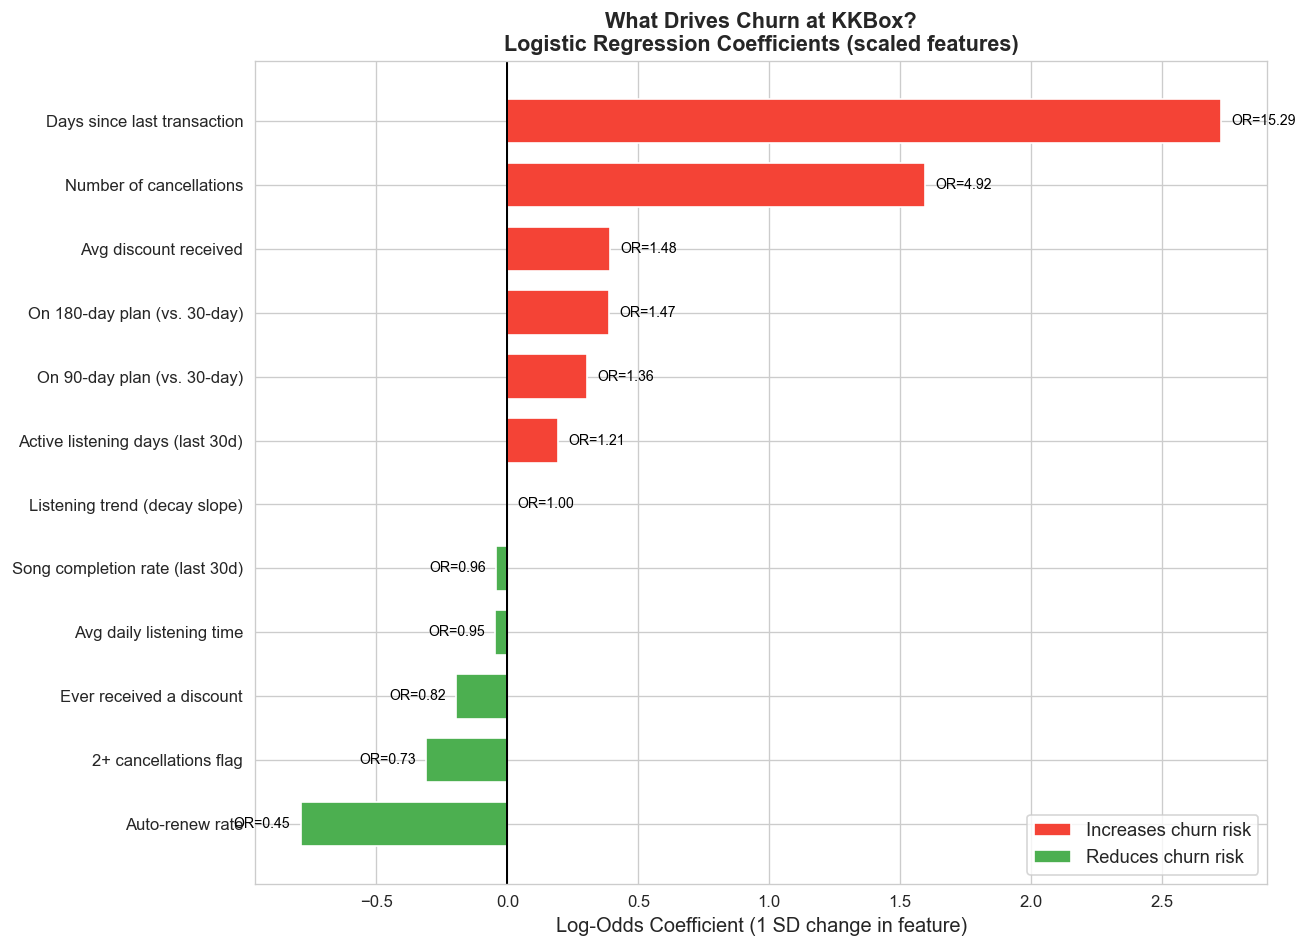

In [7]:
# Visualization: churn driver chart

fig, ax = plt.subplots(figsize=(11, 8))

colors = ["#F44336" if c > 0 else "#4CAF50" for c in driver_df["coefficient"]]
bars = ax.barh(
    driver_df["label"][::-1],
    driver_df["coefficient"][::-1],
    color=colors[::-1],
    edgecolor="white",
    height=0.7,
)

ax.axvline(x=0, color="black", linewidth=1.2)
ax.set_xlabel("Log-Odds Coefficient (1 SD change in feature)", fontsize=12)
ax.set_title("What Drives Churn at KKBox?\nLogistic Regression Coefficients (scaled features)",
             fontsize=13, fontweight="bold")

# Add odds ratio annotations
for bar, (_, row) in zip(bars[::-1], driver_df.iterrows()):
    width = bar.get_width()
    offset = 0.04 if width >= 0 else -0.04
    ha = "left" if width >= 0 else "right"
    label = f"OR={row['odds_ratio']:.2f}"
    ax.text(width + offset, bar.get_y() + bar.get_height() / 2,
            label, va="center", ha=ha, fontsize=8.5, color="black")

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#F44336", label="Increases churn risk"),
    Patch(facecolor="#4CAF50", label="Reduces churn risk"),
]
ax.legend(handles=legend_elements, fontsize=11, loc="lower right")

plt.tight_layout()
plt.savefig(DATA_DIR + "churn_drivers.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Business Interpretation

In [9]:
# Pull top risk drivers and top protective factors
risk_drivers = driver_df[driver_df["coefficient"] > 0].head(4)
protective = driver_df[driver_df["coefficient"] < 0].tail(4).iloc[::-1]

print("TOP RISK FACTORS (churn):")
print("-" * 120)
for _, row in risk_drivers.iterrows():
    print(f"  {row['label']}")
    print(f"    Odds ratio: {row['odds_ratio']:.2f}x  "
          f"({row['pct_change_in_odds']:+.1f}% higher churn odds per 1 SD increase)\n")

print("\nTOP PROTECTIVE FACTORS (retention): ")
print("-" * 120)
for _, row in protective.iterrows():
    print(f"  {row['label']}")
    print(f"    Odds ratio: {row['odds_ratio']:.2f}x  "
          f"({row['pct_change_in_odds']:+.1f}% lower churn odds per 1 SD increase)\n")

print("\nNOTE on plan-type coefficients:")
print("  Only ~1% of users are on 90-day or 180-day plans (vs. 98% on 30-day).")
print("  Plan-type coefficients should be interpreted with caution given the")
print("  small sample sizes for non-30d cohorts.")

TOP RISK FACTORS (churn):
------------------------------------------------------------------------------------------------------------------------
  Days since last transaction
    Odds ratio: 15.29x  (+1428.7% higher churn odds per 1 SD increase)

  Number of cancellations
    Odds ratio: 4.92x  (+392.3% higher churn odds per 1 SD increase)

  Avg discount received
    Odds ratio: 1.48x  (+48.0% higher churn odds per 1 SD increase)

  On 180-day plan (vs. 30-day)
    Odds ratio: 1.47x  (+47.4% higher churn odds per 1 SD increase)


TOP PROTECTIVE FACTORS (retention): 
------------------------------------------------------------------------------------------------------------------------
  Auto-renew rate
    Odds ratio: 0.45x  (-54.6% lower churn odds per 1 SD increase)

  2+ cancellations flag
    Odds ratio: 0.73x  (-26.6% lower churn odds per 1 SD increase)

  Ever received a discount
    Odds ratio: 0.82x  (-17.8% lower churn odds per 1 SD increase)

  Avg daily listening time
   

In [10]:
# Stakeholder summary table

print("=" * 65)
print("CHURN DRIVER SUMMARY -- KKBox Subscription Analysis")
print("=" * 65)
print(f"Model: Logistic Regression  |  AUC: {auc:.3f}  |  N: {len(df):,} users")
print()
print(f"{'Driver':<40s} {'Odds Ratio':>10s}  {'Effect':>20s}")
print("-" * 73)
for _, row in driver_df.iterrows():
    effect = f"+{row['pct_change_in_odds']:.0f}% risk" if row["coefficient"] > 0 \
        else f"{row['pct_change_in_odds']:.0f}% risk"
    print(f"{row['label']:<40s} {row['odds_ratio']:>10.2f}  {effect:>20s}")
print("=" * 65)
print("Odds ratio > 1 = raises churn risk | < 1 = lowers churn risk")
print("All features scaled (1 SD change); class-weighted for 6% churn imbalance")

CHURN DRIVER SUMMARY -- KKBox Subscription Analysis
Model: Logistic Regression  |  AUC: 0.967  |  N: 933,578 users

Driver                                   Odds Ratio                Effect
-------------------------------------------------------------------------
Days since last transaction                   15.29           +1429% risk
Number of cancellations                        4.92            +392% risk
Avg discount received                          1.48             +48% risk
On 180-day plan (vs. 30-day)                   1.47             +47% risk
On 90-day plan (vs. 30-day)                    1.36             +36% risk
Active listening days (last 30d)               1.21             +22% risk
Listening trend (decay slope)                  1.00               0% risk
Song completion rate (last 30d)                0.96              -4% risk
Avg daily listening time                       0.95              -5% risk
Ever received a discount                       0.82             -18% r